<a href="https://colab.research.google.com/github/Zetastico/Inteligencia-Artificial-I/blob/main/Lab5%20ClasificacionMulticlasePytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
path = '/content/drive/MyDrive/IA Dataset/dataset_sanado.csv'
df = pd.read_csv(path)

# Separar clases
df_0 = df[df['Credit_Score'] == 0]
df_1 = df[df['Credit_Score'] == 1]
df_2 = df[df['Credit_Score'] == 2]

# Balanceo (oversampling)
df_0_up = resample(df_0, replace=True, n_samples=len(df_1), random_state=42)
df_2_up = resample(df_2, replace=True, n_samples=len(df_1), random_state=42)

df_bal = pd.concat([df_1, df_0_up, df_2_up])

print(df_bal['Credit_Score'].value_counts())

Credit_Score
1    53174
0    53174
2    53174
Name: count, dtype: int64


In [39]:
print(df.dtypes)

Age                                                   float64
Annual_Income                                         float64
Monthly_Inhand_Salary                                 float64
Num_Bank_Accounts                                     float64
Num_Credit_Card                                       float64
Interest_Rate                                         float64
Num_of_Loan                                           float64
Delay_from_due_date                                     int64
Num_of_Delayed_Payment                                float64
Changed_Credit_Limit                                  float64
Num_Credit_Inquiries                                  float64
Outstanding_Debt                                      float64
Credit_Utilization_Ratio                              float64
Credit_History_Age                                      int64
Total_EMI_per_month                                   float64
Amount_invested_monthly                               float64
Monthly_

In [40]:
# 1. Separamos X del target
X_df = df_bal.drop(columns=['Credit_Score'])
y = df_bal['Credit_Score'].values

# 2. Forzamos a que TODO en X sea numérico.
# 'coerce' transformará cualquier texto rebelde o espacio en blanco en NaN
X_df = X_df.apply(pd.to_numeric, errors='coerce')

# 3. Llenamos los NaN que hayan aparecido con 0 (o con la media si prefieres)
X_df = X_df.fillna(0)

# 4. Ahora sí, convertimos a numpy array de tipo float64
X = X_df.values.astype(np.float64)

# 5. Procedemos con la normalización
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)

# Evitar división por cero
X_std[X_std == 0] = 1.0

X = (X - X_mean) / X_std

# Split manual (80% train / 20% test)
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (127617, 44) Test: (31905, 44)


In [41]:
class DatasetMulticlase(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [42]:
train_dataset = DatasetMulticlase(X_train, y_train)
test_dataset = DatasetMulticlase(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [43]:
n = X.shape[1]

model = nn.Sequential(
    nn.Linear(n, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 3)   # 3 clases
)

In [44]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [45]:
epochs = 250
best_loss = float("inf")

history_loss = []

for epoch in range(epochs):
    model.train()
    losses = []

    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    avg_loss = np.mean(losses)

    history_loss.append(avg_loss)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    avg_loss = np.mean(losses)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    # Guardar mejor modelo (checkpoint)
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "mejor_modelo_multiclase.pt")
        print("Checkpoint guardado")

Epoch 1, Loss: 0.7470
Checkpoint guardado
Epoch 2, Loss: 0.7068
Checkpoint guardado
Epoch 3, Loss: 0.6967
Checkpoint guardado
Epoch 4, Loss: 0.6917
Checkpoint guardado
Epoch 5, Loss: 0.6869
Checkpoint guardado
Epoch 6, Loss: 0.6829
Checkpoint guardado
Epoch 7, Loss: 0.6799
Checkpoint guardado
Epoch 8, Loss: 0.6783
Checkpoint guardado
Epoch 9, Loss: 0.6753
Checkpoint guardado
Epoch 10, Loss: 0.6742
Checkpoint guardado
Epoch 11, Loss: 0.6728
Checkpoint guardado
Epoch 12, Loss: 0.6698
Checkpoint guardado
Epoch 13, Loss: 0.6686
Checkpoint guardado
Epoch 14, Loss: 0.6679
Checkpoint guardado
Epoch 15, Loss: 0.6659
Checkpoint guardado
Epoch 16, Loss: 0.6650
Checkpoint guardado
Epoch 17, Loss: 0.6630
Checkpoint guardado
Epoch 18, Loss: 0.6621
Checkpoint guardado
Epoch 19, Loss: 0.6620
Checkpoint guardado
Epoch 20, Loss: 0.6612
Checkpoint guardado
Epoch 21, Loss: 0.6598
Checkpoint guardado
Epoch 22, Loss: 0.6588
Checkpoint guardado
Epoch 23, Loss: 0.6581
Checkpoint guardado
Epoch 24, Loss: 0.65

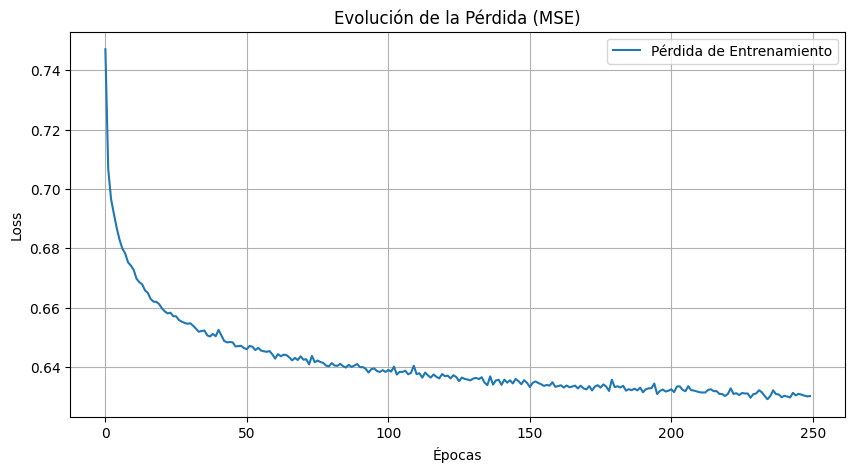

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(history_loss, label='Pérdida de Entrenamiento')
plt.title('Evolución de la Pérdida (MSE)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
model.load_state_dict(torch.load("mejor_modelo_multiclase.pt"))
model.eval()

Sequential(
  (0): Linear(in_features=44, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=3, bias=True)
)

In [48]:
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.numpy())

In [49]:
print("Matriz de confusión:\n", confusion_matrix(y_true, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_true, y_pred))

Matriz de confusión:
 [[    0     0     0]
 [    0     0     0]
 [ 1997  7639 22269]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         0
           2       1.00      0.70      0.82     31905

    accuracy                           0.70     31905
   macro avg       0.33      0.23      0.27     31905
weighted avg       1.00      0.70      0.82     31905



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
ejemplo = torch.tensor([X_test[0]], dtype=torch.float32)

with torch.no_grad():
    output = model(ejemplo)
    probs = torch.softmax(output, dim=1)
    clase = torch.argmax(probs).item()

print("Probabilidades:", probs.numpy())
print("Clase predicha:", clase)
print("Clase real:", y_test[0])

Probabilidades: [[0.10555509 0.3197746  0.57467026]]
Clase predicha: 2
Clase real: 2
